# Feature Exploration, Regularization, and Feature Importance
## Using the ACS Income Dataset via Folktables

This notebook builds on the folktables setup from the FairML notebook and uses the **ACSIncome** task — predicting whether a person earns more than **$50,000/year** — to demonstrate three core techniques:

| Technique | Question it answers |
|-----------|--------------------|
| **PCA** | What structure exists in the feature space? Which features carry the most variance? |
| **Lasso vs. Ridge** | How does L1 vs. L2 regularization affect model coefficients and sparsity? |
| **Permutation Importance** | Which features actually matter most for model performance? |

We use **Oregon 2018** data by default. See Section 2 for notes on state selection and memory limits.

### References
- [Folktables on GitHub](https://github.com/socialfoundations/folktables)
- [sklearn: Permutation Importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [sklearn: Lasso](https://scikit-learn.org/stable/modules/linear_model.html#lasso)
- [sklearn: Ridge](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)

---
## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
try:
    import folktables
    from folktables import ACSDataSource, ACSIncome
except ImportError:
    !pip install folktables -q
    import folktables
    from folktables import ACSDataSource, ACSIncome

---
## 2. Configuration

We use **Oregon 2018** as our default state — it's large enough to be interesting (~42K rows) but small enough to run comfortably on a shared JupyterHub.

> **⚠ California warning:** CA has ~400,000 rows. Even with `SAMPLE_SIZE = 50_000`, the full dataframe is downloaded and held in memory before sampling, which is enough to crash a JupyterHub kernel. Stick with smaller states unless you're running locally with plenty of RAM.

Change `STATE` below to explore other states — just be mindful of file size.

In [ ]:
STATE       = "OR"       # Oregon — swap to another state if running locally with more RAM
SURVEY_YEAR = '2018'
SAMPLE_SIZE = 50_000     # cap — set to None to use all rows
RANDOM_SEED = 42

---
## 3. Load and Subsample the Data

### ACSIncome Features

| Feature | Description |
|---------|-------------|
| `AGEP`  | Age |
| `COW`   | Class of worker (private, government, self-employed…) |
| `SCHL`  | Educational attainment |
| `MAR`   | Marital status |
| `OCCP`  | Occupation code |
| `POBP`  | Place of birth |
| `RELP`  | Relationship to household head |
| `WKHP`  | Usual hours worked per week |
| `SEX`   | Sex |
| `RAC1P` | Race |

**Target:** `PINCP > $50,000` (personal income above $50K)  
**Sensitive attribute:** `SEX` (default in ACSIncome)

In [ ]:
data_source = ACSDataSource(survey_year=SURVEY_YEAR, horizon='1-Year', survey='person')
acs_data_full = data_source.get_data(states=[STATE], download=True)

# Subsample before converting to numpy — keeps memory usage low
if SAMPLE_SIZE and len(acs_data_full) > SAMPLE_SIZE:
    acs_data = acs_data_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)
    print(f"Full CA dataset: {len(acs_data_full):,} rows  →  sampled {SAMPLE_SIZE:,} rows")
else:
    acs_data = acs_data_full
    print(f"Using full dataset: {len(acs_data):,} rows")

features, label, group = ACSIncome.df_to_numpy(acs_data)
print(f"Feature matrix: {features.shape}  |  Labels: {label.shape}")

We store the feature names as a list — we'll need them for labelling PCA axes and importance plots.

In [ ]:
FEATURE_NAMES = ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']

income_df = pd.DataFrame(features, columns=FEATURE_NAMES)
income_df['income_over_50k'] = label.astype(int)
income_df['sex'] = group.astype(int)

income_df.head()

---
## 4. Quick EDA

A fast look at the target distribution and the two most interpretable continuous features — age and hours worked — before we move into PCA.

In [ ]:
counts = income_df['income_over_50k'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['≤ $50K', '> $50K'], counts[[0, 1]], color=['#e07070', '#70a8e0'], edgecolor='black')
for bar, val in zip(ax.patches, counts[[0, 1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=11)
ax.set_title(f'Income Class Balance — Oregon {SURVEY_YEAR} (n={len(income_df):,})', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, color, lbl in zip([0, 1], ['#e07070', '#70a8e0'], ['≤ $50K', '> $50K']):
    ax.hist(income_df[income_df['income_over_50k'] == cls]['AGEP'], bins=30,
            alpha=0.6, color=color, label=lbl, edgecolor='none')
ax.set_title('Age Distribution by Income Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (AGEP)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, color, lbl in zip([0, 1], ['#e07070', '#70a8e0'], ['≤ $50K', '> $50K']):
    ax.hist(income_df[income_df['income_over_50k'] == cls]['WKHP'], bins=25,
            alpha=0.6, color=color, label=lbl, edgecolor='none')
ax.set_title('Hours Worked per Week by Income Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Hours per Week (WKHP)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. PCA — Exploring the Feature Space

**Principal Component Analysis (PCA)** is an unsupervised technique that rotates the feature space to find the directions of **maximum variance**. Each principal component (PC) is a linear combination of the original features.

We use it here for two purposes:
1. **Scree plot** — how much variance does each PC explain? How many components do we need to capture most of the information?
2. **Feature loadings** — which original features contribute most to the first two PCs?

> Note: ACS features are ordinal/categorical integers, not truly continuous. PCA still works as an exploratory tool, but the components should be interpreted as capturing *co-variation patterns* rather than pure geometric directions.

In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=len(FEATURE_NAMES), random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

### Scree Plot

The scree plot shows how much variance each PC explains. The cumulative line tells you how many components you need to reach a given threshold — a common rule of thumb is to keep enough components to explain **80–90% of variance**.

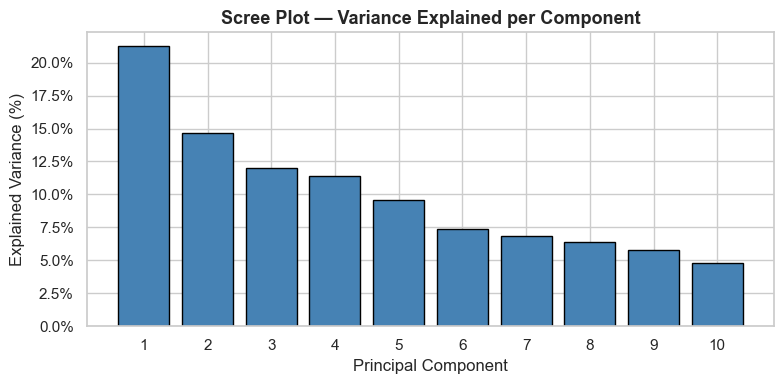

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained)+1), explained * 100, color='steelblue', edgecolor='black')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot — Variance Explained per Component', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, len(explained)+1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

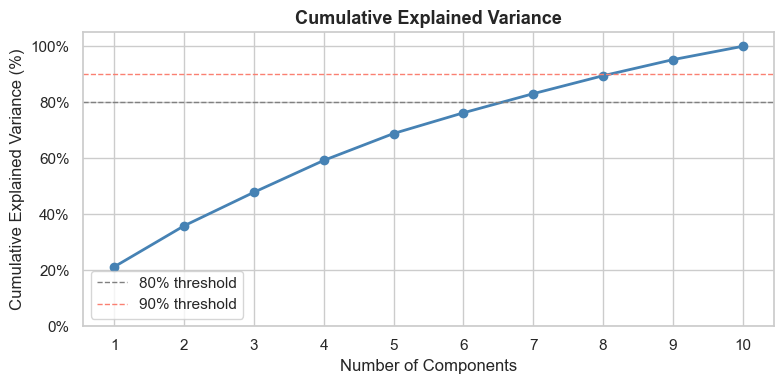

In [70]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative)+1), cumulative * 100, marker='o', color='steelblue', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax.axhline(90, color='salmon', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, len(cumulative)+1))
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

### Feature Loadings on PC1 and PC2

**Loadings** show how much each original feature contributes to a principal component — they are the weights in the linear combination that defines each PC.

- A large positive loading means the feature increases along that PC direction
- A large negative loading means the feature decreases along that PC direction
- Features near zero have little influence on that component

The **loading plot** (biplot of PC1 vs PC2 loadings) shows which features point in similar directions — features close together are correlated.

In [71]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=FEATURE_NAMES,
    columns=['PC1', 'PC2']
)
loadings

,PC1,PC2
AGEP,-0.465604,0.238240
COW,-0.273974,-0.070870
SCHL,-0.324745,-0.414768
MAR,0.496581,-0.305371
OCCP,0.301539,0.344958
POBP,0.119821,0.512383
RELP,0.436336,-0.219043
WKHP,-0.147706,0.244018
SEX,-0.055515,-0.297992
RAC1P,0.188488,0.308349


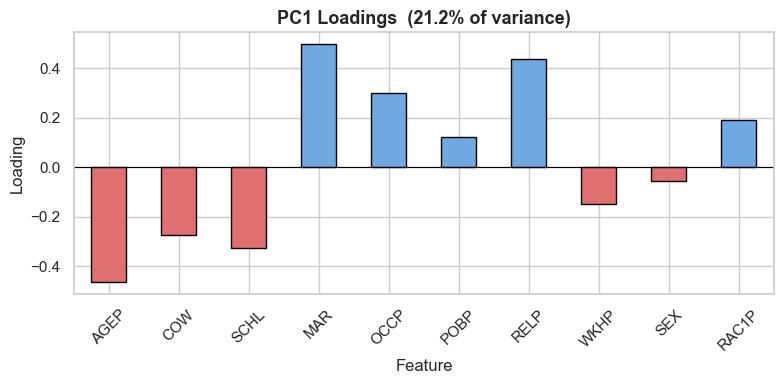

In [72]:
colors_pc1 = ['#70a8e0' if v >= 0 else '#e07070' for v in loadings['PC1']]

fig, ax = plt.subplots(figsize=(8, 4))
loadings['PC1'].plot(kind='bar', ax=ax, color=colors_pc1, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'PC1 Loadings  ({explained[0]*100:.1f}% of variance)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Loading')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

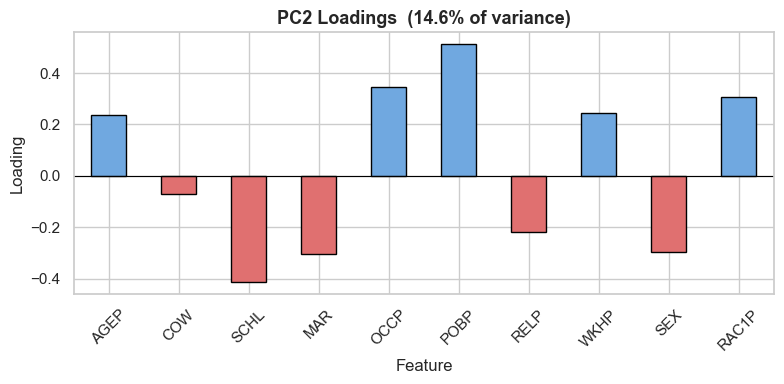

In [73]:
colors_pc2 = ['#70a8e0' if v >= 0 else '#e07070' for v in loadings['PC2']]

fig, ax = plt.subplots(figsize=(8, 4))
loadings['PC2'].plot(kind='bar', ax=ax, color=colors_pc2, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'PC2 Loadings  ({explained[1]*100:.1f}% of variance)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Loading')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

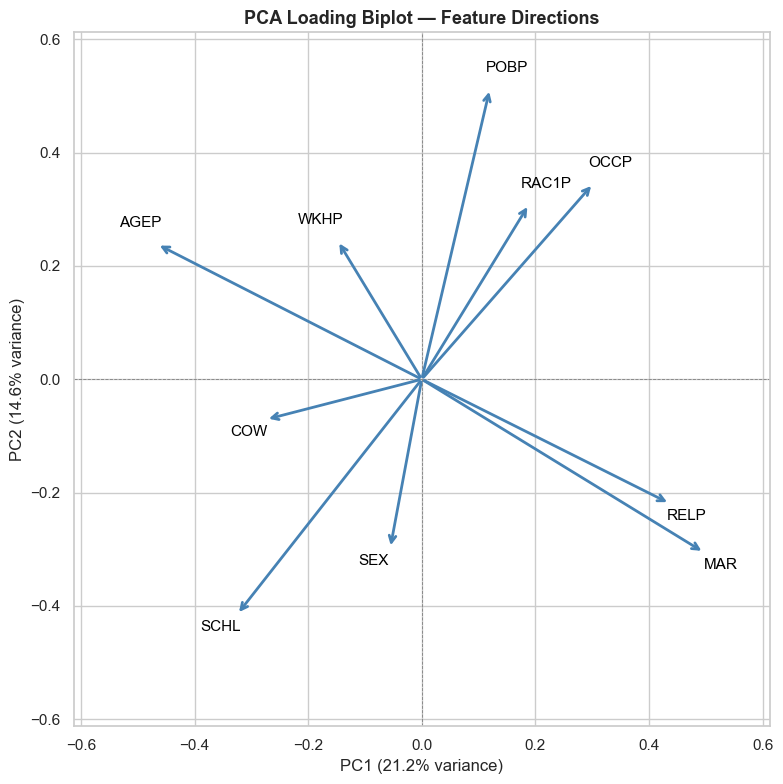

In [74]:
fig, ax = plt.subplots(figsize=(8, 8))

for feat, (pc1_val, pc2_val) in loadings.iterrows():
    ax.annotate('', xy=(pc1_val, pc2_val), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
    # Offset label slightly beyond the arrow tip
    offset = 0.03
    ax.text(pc1_val + offset * np.sign(pc1_val),
            pc2_val + offset * np.sign(pc2_val),
            feat, fontsize=11, ha='center', color='black')

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.6, linestyle='--')

# Pad axes symmetrically around the data
pad = 0.1
all_vals = np.abs(loadings.values).max()
ax.set_xlim(-all_vals - pad, all_vals + pad)
ax.set_ylim(-all_vals - pad, all_vals + pad)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Loading Biplot — Feature Directions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Projecting the Data onto PC1 and PC2

Finally, we can plot each individual in the first two PC dimensions, coloured by income class. If the two classes separate in this projection, it means the features collectively carry signal for the income prediction task — even before we've trained any model.

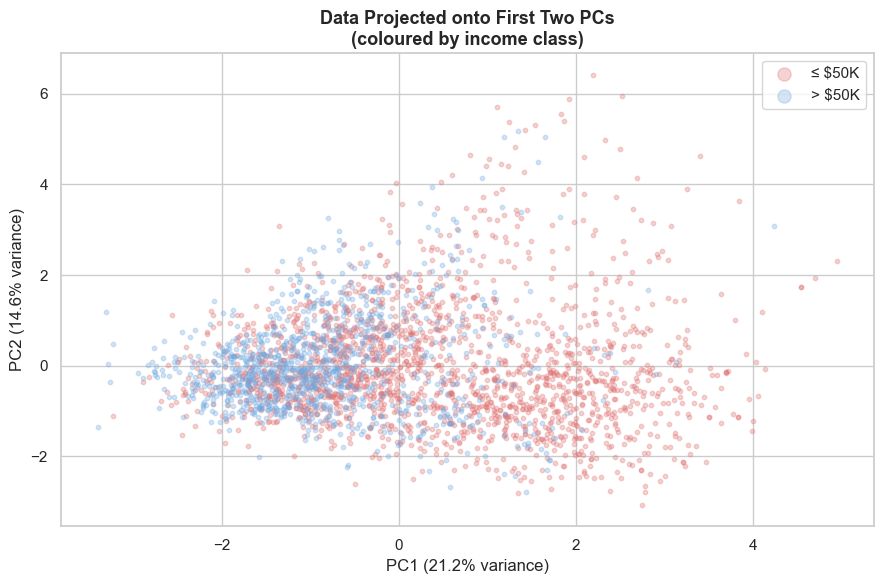

In [75]:
# Subsample for scatter plot readability
idx = np.random.default_rng(RANDOM_SEED).choice(len(X_pca), size=3000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cls, color, lbl in zip([0, 1], ['#e07070', '#70a8e0'], ['≤ $50K', '> $50K']):
    mask = label[idx] == cls
    ax.scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1],
               alpha=0.3, s=10, color=color, label=lbl)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Data Projected onto First Two PCs\n(coloured by income class)', fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()

### What did PCA tell us?

#### Variance concentration
The scree plot shows how "spread out" the information is across features. If the first 2–3 components explain most of the variance, the dataset has a low-dimensional structure — the features are correlated and redundant. If variance is spread more evenly across all components, the features are more independent and each one is adding something distinct.

#### PC1 and PC2 loadings
The loading bar charts show which features drive each component. Features with large loadings (positive or negative) on PC1 are the ones that vary together most across individuals. For income data, you'd typically expect features like hours worked (`WKHP`), education (`SCHL`), and age (`AGEP`) to have strong loadings — they correlate with each other and with income. Categorical features with many unique values (like `OCCP` — occupation) can sometimes dominate a component simply because they vary a lot, not necessarily because they're the most *predictive*.

#### The biplot
Features whose arrows point in the same direction are positively correlated. Features with arrows pointing in opposite directions are negatively correlated. Features with short arrows are largely uncaptured by the first two PCs — this doesn't mean they're unimportant, it may just mean their variance is spread across later components.

#### Implications for feature selection

PCA is **unsupervised** — it only looks at variance in the inputs, not the relationship to the target (income). This creates an important caveat:

- A feature can have **high variance** (large PCA loading) but **low predictive power** — it varies a lot but not in a way that relates to income
- A feature can have **low variance** (small PCA loading) but still be **highly predictive** — e.g., a binary feature that splits the population cleanly

So PCA loadings are a starting point, not a final answer. The right tools for assessing predictive relevance are the ones we use next — regularization paths and permutation importance. A feature that shows up as unimportant in PCA *and* gets zeroed out by Lasso *and* has near-zero permutation importance is a strong candidate for removal. Agreement across methods is the key signal.

---
## 6. Regularization — Lasso (L1) vs. Ridge (L2)

Regularization adds a **penalty term** to the loss function to discourage large coefficients. This reduces overfitting and — in the case of L1 — can also perform automatic feature selection.

For logistic regression, the two penalties are:

| | Lasso (L1) | Ridge (L2) |
|---|---|---|
| **Penalty term** | $\lambda \sum |w_i|$ | $\lambda \sum w_i^2$ |
| **Effect on coefficients** | Drives some exactly to **zero** (sparse) | Shrinks all toward zero, none exactly zero |
| **Use case** | Feature selection, sparse models | When all features are expected to contribute |
| **sklearn param** | `penalty='l1'`, `solver='liblinear'` | `penalty='l2'` (default) |
| **Strength control** | `C` = inverse of regularization strength — smaller `C` = more regularization |

We'll first compare models trained with both penalties at a default `C=1.0`, then examine how coefficients change as we vary `C`.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, label, test_size=0.2, random_state=RANDOM_SEED
)

scaler_fit = StandardScaler().fit(X_train)
X_train_s  = scaler_fit.transform(X_train)
X_test_s   = scaler_fit.transform(X_test)

### Comparing Lasso and Ridge at C = 1.0

In [ ]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=500, random_state=RANDOM_SEED)
ridge = LogisticRegression(penalty='l2', solver='lbfgs',    C=1.0, max_iter=500, random_state=RANDOM_SEED)

lasso.fit(X_train_s, y_train)
ridge.fit(X_train_s, y_train)

lasso_acc = accuracy_score(y_test, lasso.predict(X_test_s))
ridge_acc = accuracy_score(y_test, ridge.predict(X_test_s))

lasso_coef = lasso.coef_[0]
ridge_coef = ridge.coef_[0]

print(f"Lasso (L1) accuracy: {lasso_acc:.4f}  |  zero coefficients: {(lasso_coef == 0).sum()}/{len(FEATURE_NAMES)}")
print(f"Ridge (L2) accuracy: {ridge_acc:.4f}  |  zero coefficients: {(ridge_coef == 0).sum()}/{len(FEATURE_NAMES)}")

In [ ]:
x = np.arange(len(FEATURE_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, lasso_coef, width, label=f'Lasso (L1)  acc={lasso_acc:.3f}',
               color='#70a8e0', edgecolor='black')
bars2 = ax.bar(x + width/2, ridge_coef, width, label=f'Ridge (L2)  acc={ridge_acc:.3f}',
               color='#f0a070', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso vs. Ridge Coefficients (C=1.0)\nL1 drives some coefficients to zero; L2 shrinks all but keeps them non-zero',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Regularization Paths

As we decrease `C` (increase regularization strength), coefficients are shrunk more aggressively:
- **Lasso**: coefficients hit exactly zero at different points — this is the "selection" effect
- **Ridge**: coefficients shrink smoothly toward zero but never reach it

The regularization path visualizes this as `C` varies over several orders of magnitude.

In [ ]:
C_values = np.logspace(-3, 0.5, 30)  # 0.001 to ~3 — paths stabilise by C=1

lasso_coefs = []
ridge_coefs = []

for C in C_values:
    m_l = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=500, random_state=RANDOM_SEED)
    m_r = LogisticRegression(penalty='l2', solver='lbfgs',    C=C, max_iter=500, random_state=RANDOM_SEED)
    m_l.fit(X_train_s, y_train)
    m_r.fit(X_train_s, y_train)
    lasso_coefs.append(m_l.coef_[0])
    ridge_coefs.append(m_r.coef_[0])

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

In [ ]:
colors = sns.color_palette('tab10', len(FEATURE_NAMES))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (feat, color) in enumerate(zip(FEATURE_NAMES, colors)):
    ax.plot(C_values, lasso_coefs[:, i], label=feat, color=color, linewidth=1.8)
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='C=1 (default)')
ax.set_xscale('log')
ax.set_xlabel('C  (larger = less regularization →)', fontsize=11)
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso (L1) Regularization Path', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

#### Reading this chart

The x-axis is `C` on a log scale. Moving **left** means stronger regularization (more penalty on large coefficients). Moving **right** means weaker regularization (the model can use whatever weights it wants).

**What to look for:**

- **Features that stay non-zero furthest to the left** are the most important — the model refuses to drop them even under heavy penalty. In this chart, `WKHP` (hours worked per week) and `AGEP` (age) remain large even at `C = 0.001`. The model essentially can't make good predictions without them.

- **Features that collapse to zero first** (at high C, moving right to left) are the least useful — Lasso decides they're not worth the penalty cost. `COW` (class of worker) and `RAC1P` flatten toward zero relatively early.

- **Sign tells you direction:** positive coefficients (above the line) push the prediction toward income > $50K. `WKHP` and `AGEP` are positive — more hours worked and older age both predict higher income. Negative coefficients push the other way — `OCCP`, `MAR`, and `SEX` being negative reflects that certain occupations, marital statuses, and being female (SEX=2) are associated with lower predicted income in this model.

- **The dashed vertical line at C=1** is the sklearn default. Features already near zero at that point are contributing very little to the model in its default configuration.

> **Key Lasso insight:** this chart makes feature selection visual. If you needed to reduce the model to just 3 features, you'd pick the ones with the largest absolute coefficients at C=1 — here that's `WKHP`, `SCHL`, and `AGEP`.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, (feat, color) in enumerate(zip(FEATURE_NAMES, colors)):
    ax.plot(C_values, ridge_coefs[:, i], label=feat, color=color, linewidth=1.8)
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='C=1 (default)')
ax.set_xscale('log')
ax.set_xlabel('C  (larger = less regularization →)', fontsize=11)
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge (L2) Regularization Path', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Reading the Regularization Paths

- **Left (Lasso):** As `C` decreases (moving left), coefficients drop to **exactly zero** one by one. The last features to be zeroed out are the most important to the model under L1 regularization.
- **Right (Ridge):** All coefficients shrink smoothly but **never reach zero** — Ridge cannot perform feature selection, only shrinkage.

Features that retain large coefficients even under strong regularization (low `C`) are the most robust predictors — the model cannot afford to ignore them regardless of the penalty.

---
## 7. Permutation Feature Importance

**Permutation importance** answers a different question than coefficients:

> *"If I randomly shuffle the values of feature X — breaking any relationship between X and the target — how much does the model's accuracy drop?"*

A large drop means the model relied heavily on that feature. A small drop (or no drop) means the feature wasn't contributing much.

This is **model-agnostic** — it works on any fitted model, not just linear ones. It also captures non-linear relationships and interactions that coefficients can miss.

### Key differences from coefficients

| | Coefficients | Permutation Importance |
|---|---|---|
| What it measures | Linear weight in decision function | Drop in accuracy when feature is shuffled |
| Works for non-linear models? | No | Yes |
| Affected by feature scale? | Yes (even after scaling, encoding matters) | No |
| Captures interactions? | No | Partially |
| Expensive to compute? | No | Yes — repeated model evaluations |

We run permutation importance on the Ridge model (all features retained) with `n_repeats=20` — this gives us a distribution of importance scores, not just a point estimate, so we can see how stable each feature's importance is.

In [ ]:
result = permutation_importance(
    ridge, X_test_s, y_test,
    n_repeats=20,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': result.importances_mean,
    'std':        result.importances_std,
}).sort_values('importance', ascending=False)

perm_df

The error bars show the standard deviation across the 20 shuffle repeats — a wide bar means the importance estimate is noisy (the feature's contribution varies depending on which random shuffle was used). Narrow bars indicate a stable, reliable estimate.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#70a8e0' if v >= 0 else '#e07070' for v in perm_df['importance']]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors, edgecolor='black',
        error_kw=dict(elinewidth=1.2, capsize=4, ecolor='black'))
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Mean accuracy decrease when feature is shuffled', fontsize=11)
ax.set_title('Permutation Feature Importance — Ridge Model\n(error bars = std over 20 repeats)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Reading the Permutation Importance Chart

- **Long bars** — the model strongly depends on this feature. Shuffling it causes a large accuracy drop.
- **Bars near zero** — the model barely uses this feature. It could potentially be dropped.
- **Negative bars** — rare, but possible when a feature carries noise that the model partially learned to ignore; shuffling it accidentally improves predictions on this test set.

Compare this ranking back to the **PCA loadings** and **regularization paths**:
- Do the features with the largest permutation importance also have large loadings on PC1?
- Are they the last features to be zeroed out in the Lasso path?

When multiple methods agree on a feature's importance, that's a strong signal. When they disagree, it's worth investigating — PCA captures variance in the inputs, while permutation importance captures what the model actually uses to predict the output.

---
## 8. Comparing All Three Perspectives

A final summary chart putting PCA loadings on PC1, Ridge coefficients, and permutation importance side by side — normalized to [-1, 1] for visual comparability.

In [ ]:
def normalize(arr):
    """Scale to [-1, 1] by dividing by max absolute value."""
    m = np.abs(arr).max()
    return arr / m if m > 0 else arr

pc1_load   = normalize(pca.components_[0])
ridge_coef_n = normalize(ridge.coef_[0])
perm_imp   = normalize(result.importances_mean)

compare_df = pd.DataFrame({
    'PC1 Loading':            pc1_load,
    'Ridge Coefficient':      ridge_coef_n,
    'Permutation Importance': perm_imp,
}, index=FEATURE_NAMES)

# Sort by permutation importance
compare_df = compare_df.reindex(perm_df['feature'].values)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(FEATURE_NAMES))
width = 0.26
cols = ['#70a8e0', '#f0a070', '#90c490']
for i, (col, color) in enumerate(zip(compare_df.columns, cols)):
    ax.bar(x + i*width, compare_df[col], width, label=col, color=color, edgecolor='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(compare_df.index, rotation=45, ha='right')
ax.set_ylabel('Normalized score (relative to max)')
ax.set_title('Three Perspectives on Feature Importance\n(all normalized to [-1, 1] for comparability)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

We used three complementary lenses on the same dataset:

1. **PCA** revealed the structure of the feature space — which features co-vary, how many components are needed, and whether the income classes are separable in low-dimensional space.

2. **Lasso vs. Ridge** demonstrated the practical difference between L1 and L2 regularization. Lasso's sparsity is a form of automatic feature selection — under high regularization, only the most informative features survive. Ridge shrinks all coefficients proportionally but retains them all.

3. **Permutation Importance** gave a model-agnostic view of which features the fitted Ridge model actually relied on — measured directly by the accuracy hit of removing each feature's information.

### Key Takeaway

> No single importance metric tells the whole story. PCA captures input variance, coefficients capture linear decision weights, and permutation importance captures predictive contribution. When methods **agree**, you have strong evidence. When they **disagree**, that disagreement is itself informative — it often points to correlated features, non-linear relationships, or features that vary a lot without being predictive.